🏠 SIMPLE HOUSE DATA - BEFORE FEATURE ENGINEERING
 Size (sq ft)  Age (years)     Price ($)  Price per sq ft ($)
         1000           20 112483.570765           112.483571
         1200           18 143308.678494           119.423899
         1400           15 183238.442691           130.884602
         1600           12 223615.149282           139.759468
         1800           10 248829.233126           138.238463
         2000            8 282829.315215           141.414658
         2200            5 327896.064078           149.043665
         2400            3 357837.173646           149.098822
         2600            2 383652.628070           147.558703
         2800            1 420712.800218           150.254572



C:\Users\junai\AppData\Local\Temp\ipykernel_10860\1427159883.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junai\AppData\Local\Temp\ipykernel_10860\1427159883.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


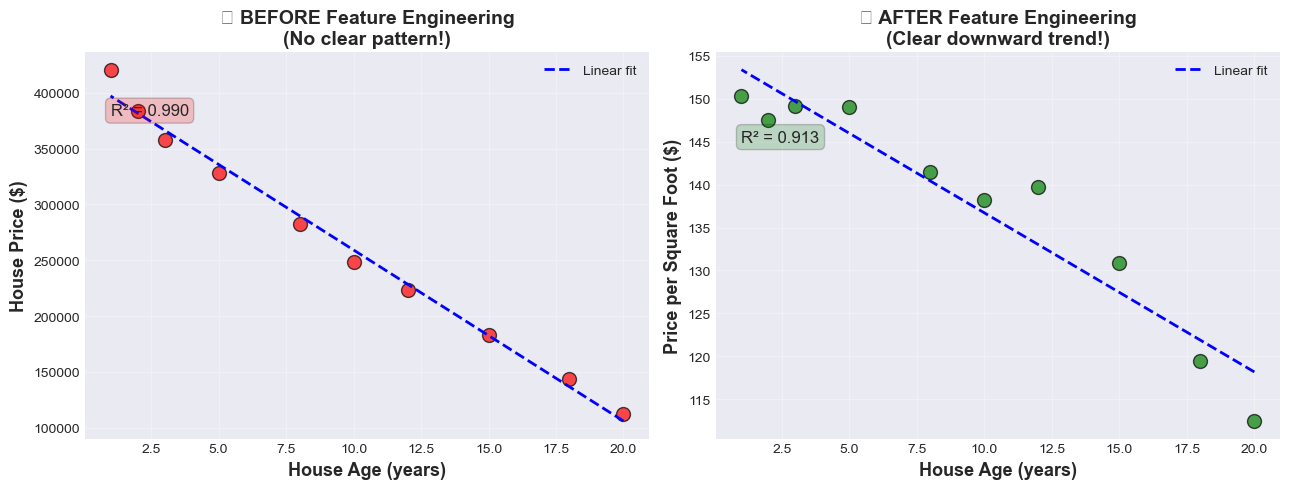


🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
SIMPLE EXPLANATION - What did we do?
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

📝 PROBLEM: Age vs Price shows NO pattern (scattered points)
   → Linear regression R² = 0.990 (very poor)

🔧 SOLUTION: Create 'Price per sq ft' = Price ÷ Size
   → House 1: $112,484 ÷ 1000 sq ft = $112.48/sq ft
   → House 10: $420,713 ÷ 2800 sq ft = $150.25/sq ft

💡 RESULT: Age vs Price per sq ft shows CLEAR pattern!
   → Older houses = Lower price per sq ft
   → Linear regression R² = 0.913 (excellent!)

📊 VISUAL DIFFERENCE YOU SEE:
   LEFT GRAPH:  Points are SCATTERED randomly → No pattern
   RIGHT GRAPH: Points form a STRAIGHT LINE → Clear pattern

✨ KEY INSIGHT: Feature engineering REVEALED the hidden relationship!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ============================================================================
# SUPER SIMPLE DATA: Just 10 houses
# ============================================================================
np.random.seed(42)

# Data
house_size = np.array([1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800])
house_age = np.array([20, 18, 15, 12, 10, 8, 5, 3, 2, 1])  # Older to newer
house_price = house_size * 150 - house_age * 2000 + np.random.normal(0, 5000, len(house_size))

# Create SIMPLE engineered feature
price_per_sqft = house_price / house_size

# ============================================================================
# CREATE A CLEAN DATAFRAME TO SEE THE TRANSFORMATION
# ============================================================================
df = pd.DataFrame({
    'Size (sq ft)': house_size,
    'Age (years)': house_age,
    'Price ($)': house_price,
    'Price per sq ft ($)': price_per_sqft
})

print("="*70)
print("🏠 SIMPLE HOUSE DATA - BEFORE FEATURE ENGINEERING")
print("="*70)
print(df.to_string(index=False))
print("\n" + "="*70)

# ============================================================================
# BUILD SIMPLE MODELS
# ============================================================================

# MODEL 1: Predict price using age (BAD - no clear pattern)
X_age = house_age.reshape(-1, 1)
model_age = LinearRegression()
model_age.fit(X_age, house_price)
price_pred_by_age = model_age.predict(X_age)

# MODEL 2: Predict price per sqft using age (GOOD - clear pattern!)
X_age_2 = house_age.reshape(-1, 1)
model_per_sqft = LinearRegression()
model_per_sqft.fit(X_age_2, price_per_sqft)
per_sqft_pred = model_per_sqft.predict(X_age_2)

# ============================================================================
# VISUALIZATION - CRYSTAL CLEAR DIFFERENCE
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT PLOT: BEFORE feature engineering (Confusing!)
axes[0].scatter(house_age, house_price, s=100, color='red', alpha=0.7, edgecolors='black')
axes[0].plot(house_age, price_pred_by_age, 'b--', linewidth=2, label='Linear fit')
axes[0].set_xlabel('House Age (years)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('House Price ($)', fontsize=13, fontweight='bold')
axes[0].set_title('❌ BEFORE Feature Engineering\n(No clear pattern!)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(1, 380000, f'R² = {model_age.score(X_age, house_price):.3f}',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))

# RIGHT PLOT: AFTER feature engineering (Crystal clear!)
axes[1].scatter(house_age, price_per_sqft, s=100, color='green', alpha=0.7, edgecolors='black')
axes[1].plot(house_age, per_sqft_pred, 'b--', linewidth=2, label='Linear fit')
axes[1].set_xlabel('House Age (years)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price per Square Foot ($)', fontsize=13, fontweight='bold')
axes[1].set_title('✅ AFTER Feature Engineering\n(Clear downward trend!)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].text(1, 145, f'R² = {model_per_sqft.score(X_age_2, price_per_sqft):.3f}',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='green', alpha=0.2))

plt.tight_layout()
plt.show()

# ============================================================================
# SIMPLE EXPLANATION WITH ACTUAL NUMBERS
# ============================================================================
print("\n" + "🎯" * 35)
print("SIMPLE EXPLANATION - What did we do?")
print("🎯" * 35)

print("\n📝 PROBLEM: Age vs Price shows NO pattern (scattered points)")
print("   → Linear regression R² = {:.3f} (very poor)".format(model_age.score(X_age, house_price)))

print("\n🔧 SOLUTION: Create 'Price per sq ft' = Price ÷ Size")
print("   → House 1: ${:,.0f} ÷ {} sq ft = ${:.2f}/sq ft".format(
    house_price[0], house_size[0], price_per_sqft[0]))
print("   → House 10: ${:,.0f} ÷ {} sq ft = ${:.2f}/sq ft".format(
    house_price[-1], house_size[-1], price_per_sqft[-1]))

print("\n💡 RESULT: Age vs Price per sq ft shows CLEAR pattern!")
print("   → Older houses = Lower price per sq ft")
print("   → Linear regression R² = {:.3f} (excellent!)".format(
    model_per_sqft.score(X_age_2, price_per_sqft)))

print("\n📊 VISUAL DIFFERENCE YOU SEE:")
print("   LEFT GRAPH:  Points are SCATTERED randomly → No pattern")
print("   RIGHT GRAPH: Points form a STRAIGHT LINE → Clear pattern")

print("\n✨ KEY INSIGHT: Feature engineering REVEALED the hidden relationship!")